# Red neuronal artificial para reconocer el tipo de un pokemon

> **Integrantes:** Eduardo Jared Montecinos, Jose Cristobal Silva, Matías Toledo

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

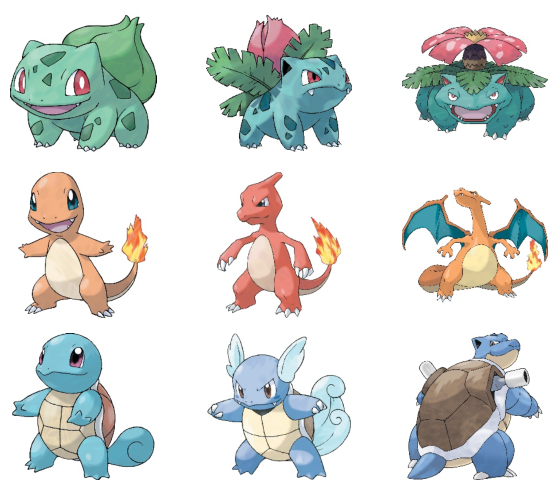

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');


In [2]:
image, label, name, attributes = dataset[0]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(9),
 'Bulbasaur',
 tensor([ 0.7000,  6.9000, 45.0000, 49.0000, 49.0000, 45.0000]))

In [3]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


In [4]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)),test_size=0.15, random_state=1234, 
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

print(f"Total imágenes: {len(train_dataset)}")

Total imágenes: 505


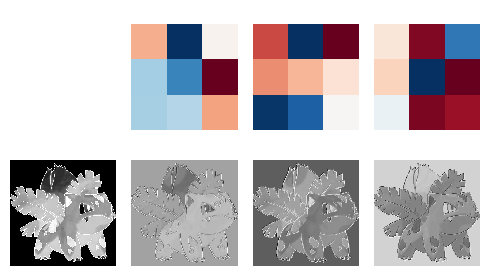

In [5]:
# Probando copiado machine learning book
import torch.nn as nn

conv_layer = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3)

example_image = train_dataset[0][0]
result = conv_layer(example_image)
example_image.shape, result.shape

fig, ax = plt.subplots(2, 4, figsize=(5, 3), tight_layout=True)
ax[1, 0].matshow(example_image[0], cmap=plt.cm.Greys)
ax[0, 0].axis('off')
ax[1, 0].axis('off')
for ax_, conv_filter in zip(ax[0, 1:], conv_layer.weight.detach().numpy()):
    ax_.matshow(conv_filter[0], cmap=plt.cm.RdBu)
    ax_.axis('off')
    
for ax_, filtered_image in zip(ax[1, 1:], result.detach().numpy()):
    ax_.matshow(filtered_image, cmap=plt.cm.Greys)
    ax_.axis('off')

### Definición del modelo

Defina e implemente un modelo apropiado para el problema. Justifique sus decisiones de diseño.

In [6]:
# soy un modelo copiado del machine learning book

import torch.nn as nn

class Lenet5(nn.Module):
    
    def __init__(self, num_classes=18):
        super(type(self), self).__init__()
        self.features = nn.Sequential(nn.Conv2d(3, 6, 5, padding=2),
                                      nn.ReLU(),
                                      nn.MaxPool2d(2),
                                      nn.Conv2d(6, 16, 5),
                                      nn.ReLU(),
                                      nn.MaxPool2d(2))
        
        self.classifier = nn.Sequential(nn.Linear(16*62*62, 120),  # <-- 62*62
                                        nn.ReLU(),
                                        nn.Linear(120, 84),
                                        nn.ReLU(),
                                        nn.Linear(84, num_classes))

    def forward(self, x):
        z = self.features(x)
        z = z.view(-1, 16*62*62)  # <-- 62*62
        return self.classifier(z)

model = Lenet5(num_classes=18)  # ajusta num_classes
print(model)

Lenet5(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=61504, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
    (4): Linear(in_features=84, out_features=18, bias=True)
  )
)


In [7]:
import torch.nn as nn

class MiCNN(nn.Module):
    def __init__(self, num_classes=18):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 256->128
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 128->64
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2) # 64->32
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*32*32, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        z = self.features(x)
        return self.classifier(z)

model = MiCNN(num_classes=18)
print(model)

MiCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=131072, out_features=512, bias=True)


In [8]:
import torchvision.models as models

model = models.resnet18(weights='IMAGENET1K_V1')

# Congelar las capas base (ya saben "ver")
for param in model.parameters():
    param.requires_grad = False

# Reemplazar solo la última capa, que sí se entrena
model.fc = nn.Linear(model.fc.in_features, 18)


### Entrenamiento del modelo

Entrene el modelo y muestre las curvas de aprendizaje. Justifique la elección de hiperparámetros.

In [ ]:
# soy un entrenamiento de modelo, copiado mahchine learning book
import torch
import torch.utils.data as tdata

total = len(train_dataset)
valid_size = int(total * 0.2)
train_size = total - valid_size

poke_train, poke_valid = tdata.random_split(train_dataset, 
                                              [train_size, valid_size], 
                                              generator=torch.Generator().manual_seed(1234))
train_loader = tdata.DataLoader(poke_train, shuffle=True, batch_size=32)
valid_loader = tdata.DataLoader(poke_valid, shuffle=False, batch_size=32)

def train_one_step(batch):
    optimizer.zero_grad()
    data, labels = batch[0], batch[1]
    data, labels = data.to(device), labels.to(device)
    preds = model.forward(data)
    loss = criterion(preds, labels)
    loss.backward()
    optimizer.step()
    loss_value = loss.item()
    del data, labels, preds, loss  # <-- libera referencias
    return loss_value

def evaluate_one_step(batch):
    with torch.no_grad():
        data, labels = batch[0], batch[1]
        data, labels = data.to(device), labels.to(device)
        preds = model.forward(data)
        loss = criterion(preds, labels)
        loss_value = loss.item()
        del data, labels, preds, loss  # <-- libera referencias
    return loss_value

def train_one_epoch(epoch):    
    train_loss, valid_loss = 0.0, 0.0
    
    model.train()  # <-- modo entrenamiento para el loop de train
    for batch in train_loader:
        train_loss += train_one_step(batch)

    model.eval()  # <-- modo evaluación para el loop de valid (clave para BatchNorm)
    for batch in valid_loader:
        valid_loss += evaluate_one_step(batch)
        
    global best_valid_loss    
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save({'epoca': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': valid_loss}, 
                   'best_model.pt')

    torch.cuda.empty_cache()
    return train_loss/len(train_loader.dataset), valid_loss/len(valid_loader.dataset)

from tqdm import tqdm

#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)  # <-- solo optimiza fc
criterion = nn.CrossEntropyLoss(reduction='sum')

#device = torch.device('cpu')
device = torch.device('cuda:0')
model = model.to(device)

max_epochs, best_valid_loss = 25, np.inf
running_loss = np.zeros(shape=(max_epochs, 2))
for epoch in tqdm(range(max_epochs)):
    running_loss[epoch] = train_one_epoch(epoch)

# Al terminar el entrenamiento, libera todo lo pesado que ya no necesitas
del optimizer
import gc
gc.collect()
torch.cuda.empty_cache()
model.eval()  # deja el modelo listo para inferencia

100%|██████████| 25/25 [00:20<00:00,  1.20it/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [10]:
batch = next(iter(train_loader))
print(type(batch))
print(len(batch))
for i, b in enumerate(batch):
    print(f"Elemento {i}: tipo={type(b)}, shape={b.shape if hasattr(b, 'shape') else 'N/A'}")

<class 'list'>
4
Elemento 0: tipo=<class 'torch.Tensor'>, shape=torch.Size([32, 3, 256, 256])
Elemento 1: tipo=<class 'torch.Tensor'>, shape=torch.Size([32])
Elemento 2: tipo=<class 'tuple'>, shape=N/A
Elemento 3: tipo=<class 'torch.Tensor'>, shape=torch.Size([32, 6])


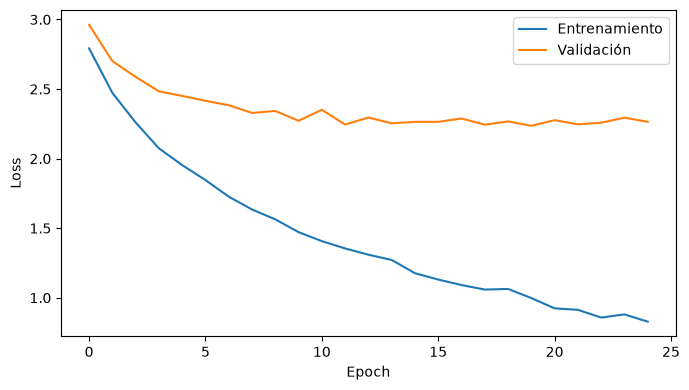

In [11]:
fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True)
ax.plot(running_loss[:, 0], label='Entrenamiento')
ax.plot(running_loss[:, 1], label='Validación')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y reporte de clasificación. Discuta los resultados.

In [13]:
# esta excelente

test_loader = tdata.DataLoader(test_dataset, shuffle=False, batch_size=32)
test_targets = np.array(test_dataset.dataset.labels)[test_dataset.indices]
prediction_test = []
model.eval()  # asegúrate que esté en modo eval
torch.cuda.empty_cache()

with torch.no_grad():  # <-- esto faltaba aquí
    for mbdata, label, name, attributes in test_loader:
        mbdata = mbdata.to(device)
        logits = model(mbdata)
        prediction_test.append(logits.argmax(dim=1).cpu().numpy())
        del mbdata, logits

prediction_test = np.concatenate(prediction_test)
torch.cuda.empty_cache()

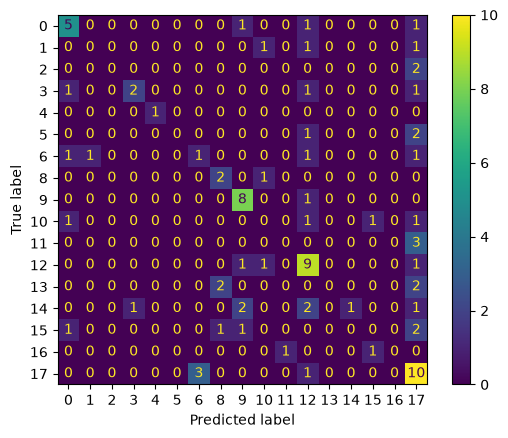

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_predictions(test_targets, prediction_test);

In [15]:
print(classification_report(test_targets, prediction_test, digits=3))

              precision    recall  f1-score   support

           0      0.556     0.625     0.588         8
           1      0.000     0.000     0.000         3
           2      0.000     0.000     0.000         2
           3      0.667     0.400     0.500         5
           4      1.000     1.000     1.000         1
           5      0.000     0.000     0.000         3
           6      0.250     0.200     0.222         5
           8      0.400     0.667     0.500         3
           9      0.615     0.889     0.727         9
          10      0.000     0.000     0.000         4
          11      0.000     0.000     0.000         3
          12      0.474     0.750     0.581        12
          13      0.000     0.000     0.000         4
          14      1.000     0.143     0.250         7
          15      0.000     0.000     0.000         5
          16      0.000     0.000     0.000         2
          17      0.357     0.714     0.476        14

    accuracy              

/mnt/windows/Informatica/Inteligencia Artificial/Trabajo Unidad 3/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/windows/Informatica/Inteligencia Artificial/Trabajo Unidad 3/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/windows/Informatica/Inteligencia Artificial/Trabajo Unidad 3/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predic

### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

In [16]:
print(test_dataset.dataset.categories)

['Bug', 'Dark', 'Dragon', 'Electric', 'Fairy', 'Fighting', 'Fire', 'Flying', 'Ghost', 'Grass', 'Ground', 'Ice', 'Normal', 'Poison', 'Psychic', 'Rock', 'Steel', 'Water']


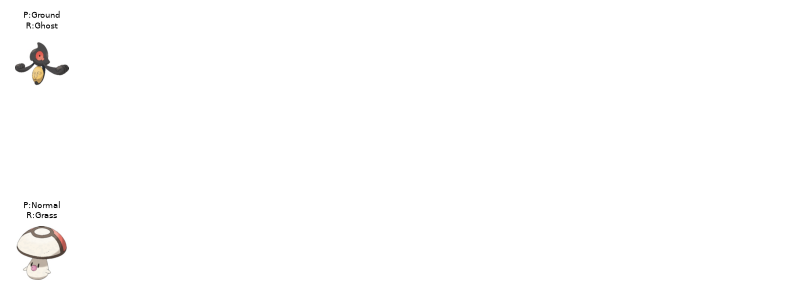

In [17]:
# wow
categories = test_dataset.dataset.categories

fig, ax = plt.subplots(3, 10, figsize=(8, 3), tight_layout=True)

for k, digit in enumerate([8, 4, 9]):
    idx = np.where((test_targets == digit) & ~(prediction_test == digit))[0]
    for i in range(10):
        ax[k, i].axis('off')
        if i < len(idx):
            real_label = test_targets[idx[i]]
            pred_label = prediction_test[idx[i]]
            real_name = categories[real_label]
            pred_name = categories[pred_label]
            ax[k, i].set_title(f"P:{pred_name}\nR:{real_name}", fontsize=6)
            ax[k, i].imshow(test_dataset[idx[i]][0].numpy().transpose(1, 2, 0))

In [18]:
del model
torch.cuda.empty_cache()

### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.

In [19]:
# wow2

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])